#EDA Summary
	•	I had the U.S. and French election tables.
	•	I created flag variables to identify which articles came from which table and then merged them.
	•	The combined DataFrame included columns like: URL, date, time, language, description, relevance, and the flag variables.
	•	I looked at the language column first and saw that the majority of the articles were in English, with around 8% in French.
	•	I decided to filter and only keep English-language texts, which left me with 3,819 articles.
	•	I checked for duplicates and found two, so I dropped them and ended up with 3,817 articles.
	•	There were two types of relevance columns — one for relevance_description and one for relevance_text.
	•	I checked for null values and saw that relevance_description had around 2,000 nulls, while relevance_text only had 7 nulls.
	•	I decided to use the relevance_text column as the truth label for my classifier model, and I’ll generate the missing 7 with an LLM.
	•	Around 16.9% of the articles were marked as relevant, which is a small proportion — this means I’ll need to use some resampling techniques later.
	•	Then I looked at the URL column and extracted the publisher from it.
	•	Turns out we have 15 unique publishers, and the top three overall were Politico, Al Jazeera, and Euronews.
	•	I also checked which publishers published the most relevant articles — top three were NBC News, Washington Post, and NPR.
	•	I examined the text length of the articles. It followed a log distribution. Most of the articles had fewer than 2,000 words.
	•	I then looked at time trends to see when the peaks happened.
	•	There was a big spike around November 2024, which aligned with the U.S. elections.
	•	There was also a smaller spike around July 2024, which matched the French legislative elections.
	•	I checked the daily spikes, and they matched up with the actual election days, which is reassuring.
	•	Around 15% of the articles were flagged as relevant for the U.S. election, while less than 1% were flagged as relevant for the French election.
	•	That means it’s going to be harder to detect French election articles due to the smaller number of examples.


In [1]:
import pandas as pd
us_df = pd.read_csv("/Users/ghadena/Desktop/geopol/data/raw/us_df.csv", index_col=0)
french_df = pd.read_csv("/Users/ghadena/Desktop/geopol/data/raw/french_df.csv", index_col=0)

# Add one-hot style flags
us_df["is_us_election"] = 1
us_df["is_french_election"] = 0
us_df["is_german_election"] = 0

french_df["is_us_election"] = 0
french_df["is_french_election"] = 1
french_df["is_german_election"] = 0

# Combine them
df = pd.concat([us_df, french_df], ignore_index=True)

In [2]:
french_df.relevance_description.value_counts()

relevance_description
0.0    875
1.0    258
Name: count, dtype: int64

In [3]:
french_df.shape

(1830, 10)

In [4]:
df.head()

,url,datetime,language,description,relevance_description,text,relevance_text,is_us_election,is_french_election,is_german_election
0,https://www.nytimes.com/2024/09/12/us/politics...,2024-09-12,en,President Biden appears on the verge of cleari...,1.0,President Biden appears on the verge of cleari...,0.0,1,0,0
1,https://www.nytimes.com/live/2024/09/09/us/har...,2024-09-09,en,As Donald J. Trump and Kamala Harris prepare f...,1.0,Donald J. Trump’s history of being physically ...,1.0,1,0,0
2,https://www.nytimes.com/2024/09/11/us/politics...,2024-09-11,en,"Within the first five minutes, Ms. Harris look...",1.0,Ms. Harris strode across the room to deliver t...,1.0,1,0,0
3,https://www.nytimes.com/video,2025-04-21,en,"Last December, video emerged showing the bodie...",0.0,NaN,0.0,1,0,0
4,https://www.nytimes.com/2024/09/09/learning/sh...,2024-09-09,en,In “Why Schools Are Racing to Ban Student Phon...,0.0,As students around the United States head back...,0.0,1,0,0


In [5]:
df.columns

Index(['url', 'datetime', 'language', 'description', 'relevance_description',
       'text', 'relevance_text', 'is_us_election', 'is_french_election',
       'is_german_election'],
      dtype='object')

language

In [6]:
df.language.value_counts()

language
en    3819
fr     338
de       4
es       2
Name: count, dtype: int64

In [7]:
# filter for eng lang 
df_eng = df[df["language"] == "en"].copy()

count = df_eng.count()
print(f"Total count: {count}")

Total count: url                      3819
datetime                 3819
language                 3819
description              3819
relevance_description    1173
text                     3774
relevance_text           3812
is_us_election           3819
is_french_election       3819
is_german_election       3819
dtype: int64


In [8]:
invalid_rows = df_eng[df_eng['text'].str.contains("nem érvényes HTML", na=False)]

print(invalid_rows)
print("Number of matching rows:", len(invalid_rows))
df_eng.shape

                                                    url    datetime language  \
121   https://www.reuters.com/technology/cybersecuri...  2024-09-11       en   
122   https://www.reuters.com/world/china-deepen-ind...  2024-09-05       en   
126   https://www.reuters.com/business/energy/nigeri...  2024-09-06       en   
128   https://www.reuters.com/fact-check/video-trump...  2024-09-05       en   
131   https://www.reuters.com/pictures/defining-imag...  2024-09-11       en   
...                                                 ...         ...      ...   
4155  https://www.rfi.fr/en/france/20240703-jean-mar...  2024-07-03       en   
4156  https://www.rfi.fr/en/france/20240702-new-cale...  2024-07-02       en   
4157  https://www.rfi.fr/en/france/20240703-france-s...  2024-07-03       en   
4158  https://www.rfi.fr/en/international-news/20240...  2024-07-04       en   
4161  https://www.rfi.fr/en/international/20240706-h...  2024-07-06       en   

                                       

(3819, 10)

In [9]:
df_eng = df_eng[~df_eng['text'].str.contains("nem érvényes HTML", na=False)]
df_eng.shape

(3531, 10)

In [10]:
df_eng = df_eng.dropna(subset=['text'])
df_eng.shape

(3486, 10)

duplicates

In [11]:
df = df_eng

In [12]:
df.shape

(3486, 10)

In [13]:
df.duplicated().sum()

np.int64(2)

In [14]:
df[df.duplicated(keep=False)]

,url,datetime,language,description,relevance_description,text,relevance_text,is_us_election,is_french_election,is_german_election
1170,https://www.politico.eu/newsletter/politico-eu...,2024-10-17,en,"By ELISA BRAUN. Tips, tales, traumas to @elisa...",NaN,"A weekly newsletter on campaigning, lobbying a...",0.0,1,0,0
1179,https://www.politico.eu/article/italy-germany-...,2024-10-15,en,The chair position is for four years but can b...,NaN,The chair position is for four years but can b...,0.0,1,0,0
1207,https://www.politico.eu/newsletter/politico-eu...,2024-10-17,en,"By ELISA BRAUN. Tips, tales, traumas to @elisa...",NaN,"A weekly newsletter on campaigning, lobbying a...",0.0,1,0,0
1217,https://www.politico.eu/article/italy-germany-...,2024-10-15,en,The chair position is for four years but can b...,NaN,The chair position is for four years but can b...,0.0,1,0,0


In [15]:
df = df.drop_duplicates(subset=["url"], keep="last")

In [16]:
df.shape

(3484, 10)

relevance description vs relevance text

In [17]:
df.relevance_description.value_counts(normalize = True)

relevance_description
0.0    0.820336
1.0    0.179664
Name: proportion, dtype: float64

In [18]:
df.relevance_description.isnull().sum()

np.int64(2471)

In [19]:
df.relevance_text.value_counts(normalize = True)

relevance_text
0.0    0.815442
1.0    0.184558
Name: proportion, dtype: float64

In [20]:
generate_truth = df[df.relevance_text.isnull()]
generate_truth

,url,datetime,language,description,relevance_description,text,relevance_text,is_us_election,is_french_election,is_german_election


url 

In [21]:
from urllib.parse import urlparse

# Example: assuming your DataFrame is called df and the URL column is named 'url'
def extract_domain(url):
    return urlparse(url).netloc

# Create a new column with just the domain names
df['publisher'] = df['url'].apply(extract_domain)

# Count how many unique news sources there are
unique_publishers = df['publisher'].nunique()
print(f"Number of unique publishers: {unique_publishers}")

# Optional: See the most common publishers
print(df['publisher'].value_counts())

Number of unique publishers: 15
publisher
www.politico.eu           702
www.aljazeera.com         548
www.euronews.com          503
www.nbcnews.com           254
www.lemonde.fr            224
www.npr.org               218
www.cnn.com               208
www.nytimes.com           189
www.rfi.fr                150
www.reuters.com           148
www.france24.com          132
www.bbc.com               121
www.washingtonpost.com     66
www.bloomberg.com          18
observers.france24.com      3
Name: count, dtype: int64


/var/folders/nx/lwphb_yx3312gqm2v4zgwnr00000gn/T/ipykernel_40729/1569481089.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['publisher'] = df['url'].apply(extract_domain)


relevance by publisher 

In [22]:
df.groupby("publisher")["relevance_text"].mean().sort_values(ascending=False)

publisher
www.nbcnews.com           0.602362
www.washingtonpost.com    0.575758
www.npr.org               0.454128
www.bloomberg.com         0.388889
www.cnn.com               0.355769
www.nytimes.com           0.312169
www.bbc.com               0.231405
www.aljazeera.com         0.120438
www.politico.eu           0.115385
www.euronews.com          0.071571
www.reuters.com           0.013514
observers.france24.com    0.000000
www.france24.com          0.000000
www.lemonde.fr            0.000000
www.rfi.fr                0.000000
Name: relevance_text, dtype: float64

Text lenght 

/var/folders/nx/lwphb_yx3312gqm2v4zgwnr00000gn/T/ipykernel_40729/2691790387.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["text_length"] = df["text"].str.split().str.len()


AttributeError: module 'matplotlib' has no attribute 'xlabel'

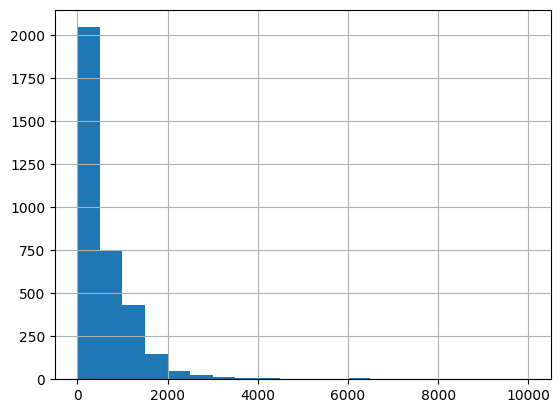

In [23]:
import matplotlib as plt 
df["text_length"] = df["text"].str.split().str.len()
max_length = int(df["text_length"].max())
bins = range(0, max_length + 500, 500)    

df["text_length"].hist(bins=bins)
plt.xlabel("Text length (words)")
plt.ylabel("Number of articles")
plt.title("Distribution of Article Lengths")
plt.show()

time trends

/var/folders/nx/lwphb_yx3312gqm2v4zgwnr00000gn/T/ipykernel_40729/3628132600.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["date"] = pd.to_datetime(df["datetime"])


<Axes: xlabel='date'>

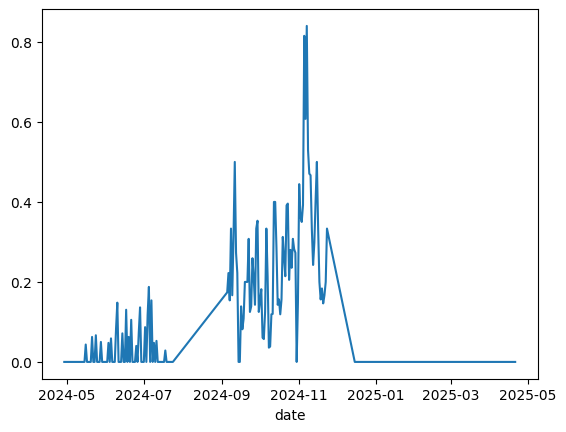

In [24]:
df["date"] = pd.to_datetime(df["datetime"])
df.groupby(df["date"].dt.date)["relevance_text"].mean().plot()

In [25]:
daily_relevance = df.groupby(df["date"].dt.date)["relevance_text"].mean()
spike_days = daily_relevance.sort_values(ascending=False).head(10)
print(spike_days)

date
2024-11-07    0.840000
2024-11-05    0.815217
2024-11-06    0.607595
2024-11-08    0.529412
2024-11-15    0.500000
2024-09-11    0.500000
2024-11-09    0.470588
2024-11-10    0.466667
2024-11-01    0.444444
2024-11-14    0.404762
Name: relevance_text, dtype: float64


In [26]:
# First, filter to relevant articles only
relevant_df = df[df["relevance_text"] == 1]

# Then get value counts with ratios
relevant_ratio_by_flag = relevant_df[["is_us_election", "is_french_election"]].sum() / len(df)
print(relevant_ratio_by_flag)

is_us_election        0.174225
is_french_election    0.010333
dtype: float64


In [27]:
print("Number of total articles:", df.shape)

print("Number of total relevant articles:", df['relevance_text'].sum())

filtered1 = df[
    (df['relevance_text']== True) &
    (df['is_french_election']== True)
]

print("Number of french relevant articles:", filtered1.shape)

filtered2 = df[
    (df['relevance_text']== True) &
    (df['is_us_election']== True)
]

print("Number of us relevant articles:", filtered2.shape)

Number of total articles: (3484, 13)
Number of total relevant articles: 643.0
Number of french relevant articles: (36, 13)
Number of us relevant articles: (607, 13)


### 📝 Data Cleaning and Filtering Summary

I began by filtering the dataset for articles written in **English**, which gave me **3,819 rows**.

1. **Invalid rows**  
   I identified **288 invalid articles** (e.g., those containing a 404 error or malformed HTML) and dropped them.  
   ➤ **Rows remaining: 3,531**

2. **Null text values**  
   I removed all rows where the `text` column was null.  
   ➤ **Rows remaining: 3,486**

3. **Duplicates**  
   I found and dropped **2 duplicate rows**.  
   ➤ **Final cleaned dataset: 3,484 rows**

4. **Relevance labeling**  
   Out of these 3,484 cleaned articles:
   - **643** were labeled as **relevant** to an election
   - Of those, only **36** were about the **French election**
   - The remaining **607** were related to the **U.S. election**

This **imbalance** in relevance labels poses a significant challenge for the classifier. It is likely to **perform better on U.S.-related content** due to the higher representation, while **struggling with French election articles** because of the limited number of positive examples.

# Feature engineering
	•	I used spaCy, an NLP library in Python, for text analysis.
	•	I used its en_core_web_sm pre-trained English language model.
	•	I wrote a function to generate reproducible features from the text data.
	•	The features included:
	•	News organization name, extracted from the article URL.
	•	Date-related features:
	•	Month
	•	Day of week
	•	Weekend indicator
	•	Election countdown flags:
	•	Number of days until the US and French elections.
	•	Word count of each article.
	•	Verb count, using spaCy’s part-of-speech tagging.
	•	Election keyword flag: if the article text mentions keywords like “election”, “vote”, “poll”, etc.
	•	Article type classification (e.g., analysis, interview, or other) based on keyword presence.
	•	Some features were left out for now because they depend on extracted entities, which I’m still generating. These include:
	•	Entity count
	•	Entity-to-word ratio
	•	Whether the article mentions any organizations
	•	After generating these features, I ran the function on my full DataFrame.
	•	I then saved the resulting featurized DataFrame to CSV for future modeling.


In [28]:
import spacy.cli
spacy.cli.download("en_core_web_sm")

ModuleNotFoundError: No module named 'spacy'

In [29]:
import pandas as pd
import numpy as np
import re
import spacy
from urllib.parse import urlparse
from datetime import datetime

# Load spaCy model (ensure it's installed with: python -m spacy download en_core_web_sm)
nlp = spacy.load("en_core_web_sm")

def generate_article_features(
    df,
    text_col="text",
    url_col="url",
    date_col="datetime",
    #entities_col="extracted_entities"
):
    df = df.copy()
    
    # Make sure date is datetime
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

    # --- News org name (from URL)
    df["news_org"] = df[url_col].apply(lambda x: urlparse(x).netloc if pd.notnull(x) else None)

    # --- Date features
    df["date"] = df[date_col].dt.date
    df["day_of_week"] = df[date_col].dt.day_name()
    df["month"] = df[date_col].dt.month
    df["is_weekend"] = df[date_col].dt.weekday >= 5
    #df["time_published"] = df[date_col].dt.time

    # --- Election countdown flags (you can customize dates)
    us_election_date = pd.to_datetime("2024-11-05")
    french_election_date = pd.to_datetime("2024-07-07")
    df["days_until_us_election"] = (us_election_date - df[date_col]).dt.days
    df["days_until_french_election"] = (french_election_date - df[date_col]).dt.days

    # --- Word count
    df["word_count"] = df[text_col].apply(lambda x: len(str(x).split()) if pd.notnull(x) else 0)

    # --- Verb count
    def count_verbs(text):
        if not isinstance(text, str): return 0
        doc = nlp(text)
        return sum(1 for token in doc if token.pos_ == "VERB")
    df["verb_count"] = df[text_col].apply(count_verbs)

    # # --- Entity count & ratio of entities to word count
    # def count_entities(entities):
    #     if not isinstance(entities, dict): return 0
    #     return sum(len(v) for v in entities.values())
    
    # df["entity_count"] = df[entities_col].apply(count_entities)
    # df["entity_to_word_ratio"] = df["entity_count"] / df["word_count"].replace(0, np.nan)

    # --- Election keyword flag
    election_keywords = ["election", "vote", "poll", "ballot", "campaign", "runoff"]
    df["mentions_election_keywords"] = df[text_col].str.contains("|".join(election_keywords), case=False, na=False)

    # # --- Mentions organization flag
    # df["mentions_organizations"] = df[entities_col].apply(
    #     lambda x: isinstance(x, dict) and len(x.get("institutions", [])) > 0
    # )

    # --- Language (pass-through if already exists, else dummy 'en')
    if "language" not in df.columns:
        df["language"] = "en"

    # --- Article type (simple heuristic)
    def get_article_type(text):
        if not isinstance(text, str): return "other"
        text = text.lower()
        if "analysis" in text: return "analysis"
        if "interview" in text: return "interview"
        return "other"
    df["article_type"] = df[text_col].apply(get_article_type)

    return df

ModuleNotFoundError: No module named 'spacy'

In [30]:
import nltk
nltk.download('punkt', download_dir='/Users/ghadena/nltk_data/tokenizers/punkt')
nltk.data.path.append('/Users/ghadena/nltk_data/tokenizers/punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/ghadena/nltk_data/tokenizers/punkt...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/ghadena/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [31]:
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/ghadena/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [32]:
from nltk import word_tokenize, pos_tag

text = "He is running for office and will vote tomorrow."
tokens = re.findall(r'\b\w+\b', text)
tags = pos_tag(tokens)
print("POS tags:", tags)

verb_count = sum(1 for _, tag in tags if tag.startswith("VB"))
print("Verb count:", verb_count)

POS tags: [('He', 'PRP'), ('is', 'VBZ'), ('running', 'VBG'), ('for', 'IN'), ('office', 'NN'), ('and', 'CC'), ('will', 'MD'), ('vote', 'VB'), ('tomorrow', 'NN')]
Verb count: 3


In [256]:
import pandas as pd
import numpy as np
import re
from urllib.parse import urlparse
from datetime import datetime
from nltk import pos_tag

# Use regex tokenizer to avoid punkt issues
def tokenize(text):
    return re.findall(r'\b\w+\b', text)

def count_verbs(text):
    if not isinstance(text, str) or not text.strip():
        return 0
    try:
        tokens = tokenize(text)
        tags = pos_tag(tokens)
        return sum(1 for _, tag in tags if tag.startswith("VB"))  # VB, VBD, VBG, etc.
    except Exception:
        return 0

def get_article_type(text):
    if not isinstance(text, str): return "other"
    intro = text[:200].lower()
    if "analysis" in intro:
        return "analysis"
    if "interview with" in intro or intro.startswith("interview:"):
        return "interview"
    return "other"

def generate_article_features(
    df,
    text_col="text",
    url_col="url",
    date_col="datetime"
):
    df = df.copy()

    # --- Ensure datetime format
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

    # --- News org name from URL
    df["news_org"] = df[url_col].apply(lambda x: urlparse(x).netloc if pd.notnull(x) else None)

    # --- Extract slug-style title from URL
    df["url_slug_title"] = df[url_col].apply(
    lambda url: (
        url.strip("/").split("/")[-2].replace("-", " ").title()
        if pd.notnull(url) and "cnn.com" in url and url.strip("/").endswith("index.html")
        else url.strip("/").split("/")[-1].replace("-", " ").title()
        if pd.notnull(url) else None)
    )

    # --- Date features
    df["date"] = df[date_col].dt.date
    df["day_of_week"] = df[date_col].dt.day_name()
    df["month"] = df[date_col].dt.month
    df["is_weekend"] = df[date_col].dt.weekday >= 5

    # --- Days until elections
    us_election_date = pd.to_datetime("2024-11-05")
    french_election_date = pd.to_datetime("2024-07-07")
    german_election_date = pd.to_datetime("2025-02-23")
    df["days_until_us_election"] = (us_election_date - df[date_col]).dt.days
    df["days_until_french_election"] = (french_election_date - df[date_col]).dt.days
    df["days_until_german_election"] = (german_election_date - df[date_col]).dt.days

    # --- Word count
    df["word_count"] = df[text_col].apply(lambda x: len(str(x).split()) if pd.notnull(x) else 0)

    # --- Sentence count (basic estimate using punctuation)
    df["sentence_count"] = df[text_col].apply(lambda x: len(re.findall(r'[.!?]', str(x))) if pd.notnull(x) else 0)

    # --- Avg sentence length
    df["avg_sentence_length"] = df.apply(
        lambda row: row["word_count"] / row["sentence_count"] if row["sentence_count"] > 0 else 0,
        axis=1
    )

    # --- Noun count
    df["noun_count"] = df[text_col].apply(
        lambda text: sum(1 for word, tag in pos_tag(tokenize(str(text))) if tag.startswith("NN")) if pd.notnull(text) else 0
    )

    # --- Verb count
    df["verb_count"] = df[text_col].apply(count_verbs)
    
    # --- 
    df["contains_question"] = df[text_col].str.contains(r"\?", na=False)
    df["quote_count"] = df[text_col].apply(lambda x: str(x).count('"') + str(x).count("“"))
    df["contains_number"] = df[text_col].str.contains(r"\d", na=False)
    df["capital_ratio"] = df[text_col].apply(
    lambda x: sum(w.isupper() for w in str(x).split()) / len(str(x).split()) if isinstance(x, str) and len(x.split()) > 0 else 0
)
    social_platforms = ["twitter", "facebook", "instagram", "tiktok", "youtube", "threads", "x.com"]

    df["mentions_social_media"] = df[text_col].apply(
    lambda x: any(p in str(x).lower() for p in social_platforms)
    )

    # --- Language fallback
    if "language" not in df.columns:
        df["language"] = "en"

    # --- Article type classification (simple heuristic)
    df["article_type"] = df[text_col].apply(get_article_type)

    return df

In [258]:
df_featurized = generate_article_features(df)

## word and verb counts - examine and create bins 

In [259]:
df_featurized.groupby("relevance_text")[["contains_question", "contains_number", "mentions_social_media"]].describe().T
#df_featurized.groupby("relevance_text")[["capital_ratio", "quote_count"]].describe().T

relevance_text                  0.0    1.0
contains_question     count    2841    643
                      unique      2      2
                      top     False  False
                      freq     2119    374
contains_number       count    2841    643
                      unique      2      2
                      top      True   True
                      freq     1935    568
mentions_social_media count    2841    643
                      unique      2      2
                      top     False  False
                      freq     2631    565

In [255]:
df_featurized.publisher.value_counts()

publisher
www.politico.eu           702
www.aljazeera.com         548
www.euronews.com          503
www.nbcnews.com           254
www.lemonde.fr            224
www.npr.org               218
www.cnn.com               208
www.nytimes.com           189
www.rfi.fr                150
www.reuters.com           148
www.france24.com          132
www.bbc.com               121
www.washingtonpost.com     66
www.bloomberg.com          18
observers.france24.com      3
Name: count, dtype: int64

In [35]:
df_featurized.verb_count.describe()

count    3484.000000
mean      101.254879
std       130.369115
min         0.000000
25%        15.750000
50%        57.000000
75%       145.000000
max      1601.000000
Name: verb_count, dtype: float64

In [36]:
bins = [-1, 15, 145, float("inf")]
labels = ["low", "medium", "high"]

df_featurized["verb_count_bin"] = pd.cut(df_featurized["verb_count"], bins=bins, labels=labels)
df_featurized["verb_count_bin"].value_counts()

verb_count_bin
medium    1743
low        871
high       870
Name: count, dtype: int64

In [37]:
df_featurized.word_count.describe()

count    3484.000000
mean      595.859357
std       749.388858
min         6.000000
25%       102.000000
50%       348.000000
75%       860.000000
max      9533.000000
Name: word_count, dtype: float64

In [38]:
bins = [-1, 100, 860, float("inf")]
labels = ["low", "medium", "high"]

df_featurized["word_count_bin"] = pd.cut(df_featurized["word_count"], bins=bins, labels=labels)
df_featurized["word_count_bin"].value_counts()

word_count_bin
medium    1747
high       870
low        867
Name: count, dtype: int64

In [39]:
df_featurized.noun_count.describe()

count    3484.000000
mean      212.560850
std       268.921697
min         2.000000
25%        44.000000
50%       123.000000
75%       302.250000
max      3709.000000
Name: noun_count, dtype: float64

In [40]:
df_featurized.groupby("relevance_text")[["word_count", "sentence_count", "avg_sentence_length", "noun_count", "verb_count"]].describe().T

relevance_text                     0.0          1.0
word_count          count  2841.000000   643.000000
                    mean    515.479409   951.006221
                    std     657.469231   989.748379
                    min       6.000000    14.000000
                    25%      49.000000   278.500000
                    50%     295.000000   773.000000
                    75%     733.000000  1255.500000
                    max    7509.000000  9533.000000
sentence_count      count  2841.000000   643.000000
                    mean     26.114044    50.771384
                    std      37.296627    60.927558
                    min       0.000000     2.000000
                    25%       4.000000    16.000000
                    50%      14.000000    37.000000
                    75%      36.000000    64.000000
                    max     534.000000   692.000000
avg_sentence_length count  2841.000000   643.000000
                    mean     19.602676    20.121854
                    std       6.623629     7.856511
                    min       0.000000     6.200000
                    25%      15.048780    16.361303
                    50%      19.957143    20.094340
                    75%      23.692308    23.617011
                    max      84.000000   171.333333
noun_count          count  2841.000000   643.000000
                    mean    185.577966   331.780715
                    std     236.595749   356.739200
                    min       2.000000     5.000000
                    25%      32.000000    99.000000
                    50%     103.000000   265.000000
                    75%     260.000000   428.500000
                    max    2947.000000  3709.000000
verb_count          count  2841.000000   643.000000
                    mean     87.579725   161.676516
                    std     115.654857   168.974941
                    min       0.000000     2.000000
                    25%       6.000000    46.000000
                    50%      49.000000   131.000000
                    75%     125.000000   221.000000
                    max    1447.000000  1601.000000

## article types 

In [41]:
df_featurized.article_type.value_counts()

article_type
other        3459
analysis       13
interview      12
Name: count, dtype: int64

In [42]:
df_featurized.columns

Index(['url', 'datetime', 'language', 'description', 'relevance_description',
       'text', 'relevance_text', 'is_us_election', 'is_french_election',
       'is_german_election', 'publisher', 'text_length', 'date', 'news_org',
       'url_slug_title', 'day_of_week', 'month', 'is_weekend',
       'days_until_us_election', 'days_until_french_election',
       'days_until_german_election', 'word_count', 'sentence_count',
       'avg_sentence_length', 'noun_count', 'verb_count',
       'election_keyword_count', 'triggered_keyword',
       'mentions_election_keywords', 'article_type', 'verb_count_bin',
       'word_count_bin'],
      dtype='object')

In [193]:
def find_trigger_in_middle_body(text, keywords, cutoff_ratio=0.05):
    if not isinstance(text, str): return None
    words = text.split()
    if len(words) < 5:  # handle very short text safely
        return None

    start = int(len(words) * cutoff_ratio)
    end = int(len(words) * (1 - cutoff_ratio))
    middle_text = " ".join(words[start:end])
    
    for kw in keywords:
        if re.search(rf"\b{re.escape(kw)}\b", middle_text, flags=re.IGNORECASE):
            return kw
    return None


In [194]:
election_keywords = [
    "election", "elections", "vote", "voting", "campaign", 
]


df_featurized["election_keyword_count"] = df_featurized["text"].apply(
    lambda text: sum(
        bool(re.search(rf"\b{re.escape(kw)}\b", str(text), flags=re.IGNORECASE))
        for kw in election_keywords
    )
)
df_featurized["triggered_keyword"] = df_featurized["text"].apply(
    lambda text: find_trigger_in_middle_body(text, election_keywords)
)
df_featurized["mentions_election_keywords"] = df_featurized["triggered_keyword"].notna()

In [195]:
df_featurized["triggered_keyword"].value_counts()

triggered_keyword
election     755
campaign     215
vote         100
elections     95
voting        13
Name: count, dtype: int64

In [196]:
print(escaped_keywords)
print(election_keywords)

['election', 'elections', 'vote', 'voting', 'campaign']
['election', 'elections', 'vote', 'voting', 'campaign']


In [199]:
# Do keywords appear in text but not middle body?
df_featurized[
    (df_featurized["election_keyword_count"] > 0) &
    (df_featurized["triggered_keyword"].isna())
][["text", "election_keyword_count"]].sample(3)

,text,election_keyword_count
1500,Above is an image related to one of the news s...,1
183,ADVERTISEMENT 2024 has been quite the year fo...,1
2733,ADVERTISEMENT Although she used the word ‘env...,1


In [201]:
df_featurized[["text", "triggered_keyword", "election_keyword_count"]].sample(15)

,text,triggered_keyword,election_keyword_count
491,World exclusive: Jailed tycoon She Zhijiang’s ...,None,0
2669,A megadott tartalom ('None') nem HTML tartalom...,None,0
1739,Good afternoon. This is Andrew McDonald. TUES...,election,4
2177,This live page is now closed. You can continue...,None,0
3855,We want to be ready for any repeat of Storm Ar...,None,0
2512,Two flight attendants wearing the pins had com...,None,0
1808,ADVERTISEMENT As images of Valencia’s devasta...,None,0
2884,Értem a kérését. Azonban a megadott tartalom (...,None,0
3919,ADVERTISEMENT There’s good news for wildlife ...,None,0
317,"A network of ""trusted investors"" will be launc...",None,0


## sanity check - Check for articles that mention election keywords but are not actually relevant

In [197]:
#df_featurized.triggered_keyword.tolist()

In [198]:
false_positives = df_featurized[
    (df_featurized["mentions_election_keywords"]) &
    (df_featurized["relevance_text"] == 0)
]

print(f"Election keyword false positives: {len(false_positives)}")
false_positives[["text", "mentions_election_keywords", "relevance_text", "triggered_keyword"]].head()

true_positives = df_featurized[
    (df_featurized["mentions_election_keywords"]) &
    (df_featurized["relevance_text"] == 1)
]

print(f"Election keyword true positives: {len(true_positives)}")
true_positives[["text", "mentions_election_keywords", "relevance_text"]].head()


Election keyword false positives: 594
Election keyword true positives: 584


,text,mentions_election_keywords,relevance_text
1,Donald J. Trump’s history of being physically ...,True,1.0
5,"“We want to move forward together, and it just...",True,1.0
9,For most of the 90-minute debate between forme...,True,1.0
11,"For years, former President Donald J. Trump ha...",True,1.0
14,Mr. Trump — who spent four years overseeing th...,True,1.0


In [181]:
# Grab one suspicious case
fp = false_positives[["text", "triggered_keyword", "url"]].sample(10).iloc[5]
print("TRIGGERED KEYWORD:", fp["triggered_keyword"])
print("TEXT:\n", fp["text"])
print("URL: \n", fp["url"])

TRIGGERED KEYWORD: campaign
TEXT:
 Case revolves around what the US says was an attempt to kill a prominent Sikh separatist leader, Gurpatwant Singh Pannun.  The United States has filed charges against an Indian government employee it says was involved in a failed plot to kill an American citizen, who is a prominent advocate for Sikh separatism, in New York.  The US Attorney’s Office for the Southern District of New York announced on Thursday that it filed “murder-for-hire and money laundering charges” against Vikash Yadav.  Another suspect in the case, Nikhil Gupta, was extradited to the US earlier this year to face charges while Yadav remains at large, according to US authorities.  “The defendant [Yadav], an Indian government employee, allegedly conspired with a criminal associate and attempted to assassinate a US citizen on American soil for exercising their First Amendment rights,” Christopher Wray, the director of the Federal Bureau of Investigation (FBI), said in a statement.  “T

In [107]:
import re
matches = re.findall(rf"\b{re.escape(fp['triggered_keyword'])}\b", fp["text"], flags=re.IGNORECASE)
print("REGEX MATCHES FOUND:", matches)

REGEX MATCHES FOUND: ['campaign', 'campaign']


In [108]:
df_featurized.iloc[76].url

'https://www.npr.org/2024/09/05/nx-s1-5101684/preventing-school-shootings'

In [109]:
df_featurized.iloc[76].text

'What research says about preventing school shootings  toggle caption Peter Zay/Anadolu via Getty Images  Wednesday\'s violence at a Georgia high school and the arrest of a 14-year-old suspect follow a familiar pattern of previous school shootings. After every one, there\'s been a tendency to ask, "How do we prevent the next one?"  For years, school safety experts, and even the U.S. Secret Service, have rallied around some very clear answers. Here\'s what they say.    It\'s not a good idea to arm teachers  There\'s broad consensus that arming teachers is not a good policy. That\'s according to Matthew Mayer, a professor at Rutgers Graduate School of Education. He\'s been studying school violence since before Columbine, and he\'s part of a group of researchers who have published several position papers about why school shootings happen.  Sponsor Message  Mayer says arming teachers is a bad idea "because it invites numerous disasters and problems, and the chances of it actually helping a

In [110]:
true_positives = df_featurized[
    (df_featurized["mentions_election_keywords"]) &
    (df_featurized["relevance_text"] == 1)
]

print(f"Election keyword true positives: {len(true_positives)}")
true_positives[["text", "mentions_election_keywords", "relevance_text"]].head()

Election keyword true positives: 401


,text,mentions_election_keywords,relevance_text
1,Donald J. Trump’s history of being physically ...,True,1.0
21,Vice President Kamala Harris’s campaign posted...,True,1.0
23,So just how emphatic was her win? And what do ...,True,1.0
34,Philadelphia CNN — Kamala Harris baited Donal...,True,1.0
37,CNN — Donald Trump unveiled a slate of new ec...,True,1.0


In [111]:
df_featurized.relevance_text.value_counts()

relevance_text
0.0    2841
1.0     643
Name: count, dtype: int64

### 🧹 Improved Election Keyword Matching: Mid-Body Filtering

To reduce false positives caused by newsletter footers and introductory blurbs, we refined our keyword matching strategy. Instead of searching for election-related keywords across the entire article, we restricted our search to the **middle 80%** of the text — excluding the top 10% and bottom 10% of each article.

This approach helps eliminate misleading keyword hits that appear:
- In **footers** (e.g., “Subscribe to the EU Election Playbook”)
- In **boilerplate introductions** or headers

We also added a diagnostic feature, `election_keyword_count`, which captures how many election-related terms appear overall. However, the final binary flag `mentions_election_keywords` is based only on matches found in the **core content zone**.

#### ✅ Results:
- **430** out of **643** truly relevant articles were correctly flagged
- **False positives dropped to 270**, down from ~800 previously

This mid-body filtering strategy offers a strong balance between **precision** and **recall**, and can be further tuned with article-specific context or model-assisted filtering.

## title 

In [202]:
df_featurized.url_slug_title.to_list()

['Biden Ukraine Weapons.Html',
 'Harris Trump Election',
 'Trump Harris Debate Takeaways.Html',
 'Should Schools Ban Student Phones.Html',
 'Harris Trump Election',
 'Iran Russia Missiles Ukraine.Html',
 'Harris Trump Debate.Html',
 'Openai Fund Raising Valuation.Html',
 'Trump Debate Dark Picture.Html',
 'Jobs College Graduates Unemployment.Html',
 'Trump Debate Migrants.Html',
 'Openai Chatgpt Math.Html',
 'Elon Musk Donald Trump Influence.Html',
 'Trump Rally Wisconsin.Html',
 'Apple Event Iphone 16 Watch.Html',
 'Trump Dead Cats Migrants Ohio.Html',
 'Japan Industrial Policy Rapidus.Html',
 'Kyoto Canals Rivers Streams.Html',
 'Nexus Yuval Noah Harari.Html',
 'Donald Trump Policy Positions',
 'Kamala Harris Campaign Platform Website',
 'Kamala Harris Policy Positions',
 'Kamala Harris Debate Performance Polls',
 'Kamala Harris Immigration',
 'Change Healthcare Letter Hack Data Breach',
 'Nexus Yuval Noah Harari Review',
 'Liane Moriarty Here One Moment',
 'Kamala Harris Abortion',


In [220]:

# Clean up .html endings
df_featurized["url_slug_title"] = df_featurized["url_slug_title"].str.replace(r"\.html?$", "", case=False, regex=True)

# Add opaque source flag
df_featurized["no_title"] = df_featurized["publisher"].isin(["www.bbc.com", "www.npr.org"])



In [221]:
# Title word count
df_featurized["title_word_count"] = df_featurized["url_slug_title"].apply(
    lambda x: len(tokenize(x)) if pd.notnull(x) else 0
)

# Title verb count using your count_verbs() function
df_featurized["title_verb_count"] = df_featurized["url_slug_title"].apply(
    lambda x: count_verbs(x) if pd.notnull(x) else 0
)

# Capitalized word ratio
df_featurized["title_capital_ratio"] = df_featurized["url_slug_title"].apply(
    lambda x: sum(w.istitle() for w in tokenize(x)) / len(tokenize(x)) if pd.notnull(x) and tokenize(x) else 0
)

# Mentions election keyword in title
election_keywords = ["election", "vote", "campaign", "ballot", "runoff"]
df_featurized["title_mentions_election"] = df_featurized["url_slug_title"].apply(
    lambda x: any(kw in x.lower() for kw in election_keywords) if pd.notnull(x) else False
)

In [224]:
# True positives: title mentions election keyword AND the article is actually relevant
title_tp = df_featurized[
    (df_featurized["title_mentions_election"]) &
    (df_featurized["relevance_text"] == 1)
]

# False positives: title mentions election keyword BUT article is not actually relevant
title_fp = df_featurized[
    (df_featurized["title_mentions_election"]) &
    (df_featurized["relevance_text"] == 0)
]

print("Title-based True Positives:", len(title_tp))
print("Title-based False Positives:", len(title_fp))

Title-based True Positives: 185
Title-based False Positives: 208


In [231]:
title_fp[["url", "publisher", "url_slug_title", "no_title", "relevance_text", "title_mentions_election"]]

,url,publisher,url_slug_title,no_title,relevance_text,title_mentions_election
100,https://www.bbc.com/news/articles/cdjw0v3zx4ko...,www.bbc.com,Cdjw0V3Zx4Ko?At_Bbc_Team=Editorial&At_Link_Ori...,True,0.0,True
107,https://www.aljazeera.com/news/2024/9/8/algeri...,www.aljazeera.com,Algerias Abdelmadjid Tebboune Re Elected Presi...,False,0.0,True
151,https://www.politico.eu/article/fbi-dossier-re...,www.politico.eu,Fbi Dossier Reveals Russian Psy Ops Disinforma...,False,0.0,True
311,https://www.politico.eu/article/eu-country-vot...,www.politico.eu,Eu Country Vote On Chinese Ev Duties Delayed,False,0.0,True
426,https://www.cnn.com/2024/09/25/politics/govern...,www.cnn.com,Government Shutdown House Vote Tally Dg,False,0.0,True
...,...,...,...,...,...,...
4096,https://www.lemonde.fr/en/international/articl...,www.lemonde.fr,Uk General Election Labour S Historic Victory ...,False,0.0,True
4098,https://www.lemonde.fr/en/international/articl...,www.lemonde.fr,Uk General Election Keir Starmer The Architect...,False,0.0,True
4105,https://www.lemonde.fr/en/les-decodeurs/articl...,www.lemonde.fr,French Elections Which Parties Refused Tactica...,False,0.0,True
4150,https://www.rfi.fr/en/france/20240702-tues-8am...,www.rfi.fr,20240702 Tues 8Am Results From First Round Of ...,False,0.0,True


In [233]:
df_featurized[df_featurized["url_slug_title"] == "French Elections Which Parties Refused"]

,url,datetime,language,description,relevance_description,text,relevance_text,is_us_election,is_french_election,is_german_election,...,triggered_keyword,mentions_election_keywords,article_type,verb_count_bin,word_count_bin,no_title,title_word_count,title_verb_count,title_capital_ratio,title_mentions_election


In [210]:
df_featurized.columns

Index(['url', 'datetime', 'language', 'description', 'relevance_description',
       'text', 'relevance_text', 'is_us_election', 'is_french_election',
       'is_german_election', 'publisher', 'text_length', 'date', 'news_org',
       'url_slug_title', 'day_of_week', 'month', 'is_weekend',
       'days_until_us_election', 'days_until_french_election',
       'days_until_german_election', 'word_count', 'sentence_count',
       'avg_sentence_length', 'noun_count', 'verb_count',
       'election_keyword_count', 'triggered_keyword',
       'mentions_election_keywords', 'article_type', 'verb_count_bin',
       'word_count_bin'],
      dtype='object')

In [213]:
df_featurized["publisher"].value_counts()

publisher
www.politico.eu           702
www.aljazeera.com         548
www.euronews.com          503
www.nbcnews.com           254
www.lemonde.fr            224
www.npr.org               218
www.cnn.com               208
www.nytimes.com           189
www.rfi.fr                150
www.reuters.com           148
www.france24.com          132
www.bbc.com               121
www.washingtonpost.com     66
www.bloomberg.com          18
observers.france24.com      3
Name: count, dtype: int64

In [216]:
df_featurized[df_featurized["publisher"] == "www.bbc.com"].url.to_list()

['https://www.bbc.com/news/articles/cn9l9500vg7o',
 'https://www.bbc.com/news/articles/c2501n5rvvno',
 'https://www.bbc.com/news/articles/credy50z4j1o',
 'https://www.bbc.com/news/articles/c74j2lz88pwo',
 'https://www.bbc.com/news/articles/c20rq73p3z4o',
 'https://www.bbc.com/news/world-us-canada-35318432',
 'https://www.bbc.com/news/videos/c4gl323r1y6o',
 'https://www.bbc.com/news/articles/cd9dwxexp77o',
 'https://www.bbc.com/news/articles/cdjw0v3zx4ko?at_bbc_team=editorial&at_link_origin=BBCNorfolk&at_ptr_name=twitter&at_format=link&at_campaign_type=owned&at_link_id=3E0C0758-6CDF-11EF-8E5C-81D8AB209D27&at_link_type=web_link',
 'https://www.bbc.com/news/articles/c62421le4j6o',
 'https://www.bbc.com/news/articles/c7810y11dyjo',
 'https://www.bbc.com/news/articles/crl8d0x9lpdo',
 'https://www.bbc.com/news/articles/cvglm0rjy2go',
 'https://www.bbc.com/news/topics/cdd52egw86mt?page=15',
 'https://www.bbc.com/news/topics/cjkm52r6krxt?page=4',
 'https://www.bbc.com/news/topics/c27968gyw7rt?

In [235]:
df_featurized.election_keyword_count.value_counts()

election_keyword_count
0    2264
1     540
2     362
3     176
4     110
5      32
Name: count, dtype: int64

In [239]:
df_featurized.title_word_count.value_counts()

title_word_count
11    407
10    368
12    337
9     334
13    261
8     239
7     217
5     196
6     195
14    183
4     169
3     151
15    119
1      96
16     66
17     56
2      48
18     16
19      9
20      6
21      3
23      3
22      3
28      1
25      1
Name: count, dtype: int64

## more features

In [0]:
#df_featurized.to_csv("df_featurized_us_french_no_entities.csv", index=False)